# Math 441 Convex Optimization

In [2]:
import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lxml import etree

here i am just playing around with the spreadsheet from https://www.transtats.bts.gov/AverageFare/

In [3]:
fare_file = "data/AverageFare_Q3_2025.xls"

parser = etree.XMLParser(recover=True)
tree = etree.parse(fare_file, parser)
root = tree.getroot()

ns = {"ss": "urn:schemas-microsoft-com:office:spreadsheet"}

worksheet = root.find("ss:Worksheet", ns)
rows = worksheet.findall(".//ss:Row", ns)

data_rows = []

for row in rows[2:]:   # skip title row + header row
    values = []
    current_col = 1

    for cell in row.findall("ss:Cell", ns):
        idx = cell.attrib.get("{urn:schemas-microsoft-com:office:spreadsheet}Index")
        if idx is not None:
            current_col = int(idx)

        data = cell.find("ss:Data", ns)
        text = data.text if data is not None else None

        values.append((current_col, text))
        current_col += 1

    row_dict = {}
    for col_idx, val in values:
        row_dict[col_idx] = val

    data_rows.append(row_dict)

fare_df = pd.DataFrame(data_rows)

fare_df = fare_df.rename(columns={
    1: "PassengerRank",
    2: "AirportCode",
    3: "AirportName",
    4: "CityName",
    5: "StateName",
    6: "AverageFare",
    7: "InflAdjAverageFare",
    8: "Passengers2024"
})

fare_df = fare_df[[
    "PassengerRank", "AirportCode", "AirportName", "CityName",
    "StateName", "AverageFare", "InflAdjAverageFare", "Passengers2024"
]].copy()

fare_df["PassengerRank"] = pd.to_numeric(fare_df["PassengerRank"], errors="coerce")
fare_df["AverageFare"] = pd.to_numeric(fare_df["AverageFare"], errors="coerce")
fare_df["InflAdjAverageFare"] = pd.to_numeric(fare_df["InflAdjAverageFare"], errors="coerce")
fare_df["Passengers2024"] = pd.to_numeric(fare_df["Passengers2024"], errors="coerce")

fare_df = fare_df.dropna(subset=["AirportCode", "AverageFare"]).reset_index(drop=True)

fare_df.head()

,PassengerRank,AirportCode,AirportName,CityName,StateName,AverageFare,InflAdjAverageFare,Passengers2024
0,1.0,LAX,Los Angeles International,Los Angeles,CA,401.386906,401.386906,1284083.0
1,2.0,ORD,Chicago O'Hare International,Chicago-O'Hare,IL,347.852650,347.852650,1089038.0
2,3.0,DEN,Denver International,Denver,CO,341.938870,341.938870,1023630.0
3,4.0,ATL,Hartsfield-Jackson Atlanta International,Atlanta,GA,410.818764,410.818764,1012618.0
4,5.0,BOS,Logan International,Boston,MA,355.813176,355.813176,986868.0


### Variables and Parameters

| Symbol | Description | Type |
|---|---|---|
| $i \in A$ | Index for airlines (or airport options) included in the model | Index |
| $A$ | Set of airlines (or airport options) being considered | Set |
| $x_i$ | Premium charged for airline $i$ as a fraction of ticket price | Decision variable |
| $y_i$ | Compensation paid for airline $i$ as a fraction of ticket price if a delay occurs | Decision variable |
| $P_i = x_i T_i$ | Actual premium charged for airline $i$ | Derived variable |
| $C_i = y_i T_i$ | Actual compensation paid for airline $i$ if a delay occurs | Derived variable |
| $T_i$ | Average ticket fare for airline $i$ | Parameter |
| $q_i$ | Probability of delay for airline $i$ | Parameter |
| $k_i$ | Premium sensitivity parameter for airline $i$; higher values mean customers dislike higher premiums more | Parameter |
| $m_i$ | Compensation sensitivity parameter for airline $i$; higher values mean customers value compensation more | Parameter |
| $\bar{x}_i$ | Upper bound on the premium fraction for airline $i$ | Parameter |
| $\bar{y}_i$ | Upper bound on the compensation fraction for airline $i$ | Parameter |
| $L_i$ | Minimum attractiveness level required for airline $i$ | Parameter |
| $B$ | Total expected compensation budget across all airlines | Parameter |
| $\lambda$ | Risk-aversion parameter that controls the strength of the quadratic penalty | Parameter |
| $\delta$ | Diversification bound limiting how concentrated compensation fractions can be | Parameter |

In [4]:
# sample data for 12 airlines
airline_df = pd.DataFrame({
    "Airline": [
        "Air Canada",
        "WestJet",
        "Porter Airlines",
        "Flair Airlines",
        "United Airlines",
        "American Airlines",
        "Delta Air Lines",
        "Alaska Airlines",
        "JetBlue Airways",
        "Southwest Airlines",
        "Spirit Airlines",
        "Frontier Airlines"
    ],
    "AverageFare": [
        320, 280, 250, 190,
        340, 330, 350, 310,
        270, 260, 210, 200
    ],
    "DelayProb": [
        0.22, 0.18, 0.15, 0.27,
        0.20, 0.24, 0.17, 0.16,
        0.21, 0.19, 0.29, 0.28
    ],
    "PremiumSensitivity": [
        1.20, 1.15, 1.10, 1.35,
        1.18, 1.22, 1.16, 1.12,
        1.25, 1.14, 1.30, 1.28
    ],
    "CompSensitivity": [
        1.80, 1.75, 1.70, 1.95,
        1.82, 1.85, 1.78, 1.74,
        1.76, 1.72, 1.90, 1.88
    ]
})

airlines = list(airline_df["Airline"])
A = range(len(airlines))
nA = len(airlines)

T = airline_df["AverageFare"].to_numpy()
q = airline_df["DelayProb"].to_numpy()
k = airline_df["PremiumSensitivity"].to_numpy()
m = airline_df["CompSensitivity"].to_numpy()

# Upper bounds on premium and compensation fractions
x_bar = np.array([0.20] * nA)   # premium up to 20% of ticket fare
y_bar = np.array([1.00] * nA)   # compensation up to 100% of fare

# Minimum attractiveness level L_i
L = np.array([20.0] * nA)

# Expected payout budget
B = 450.0

# Risk aversion parameter
lam = 0.001
delta = 2

In [5]:
# Decision variables
x = cp.Variable(nA)   # premium fraction
y = cp.Variable(nA)   # compensation fraction

## Constraints

### 1. Expected Compensation Budget Constraint

The insurer must keep the total expected payout across all airlines within a fixed budget $B$. Since the expected payout for airline $i$ is the delay probability multiplied by the compensation amount, this gives:

$$
\sum_{i \in A} q_i y_i T_i \leq B
$$

In [6]:
constraints = []
constraints.append(cp.sum(cp.multiply(q * T, y)) <= B)

### 2. Premium Bounds

The premium charged for each airline must be nonnegative and cannot exceed a chosen upper bound $\bar{x}_i$:

$$
0 \leq x_i \leq \bar{x}_i, \qquad \forall i \in A
$$

In [7]:
for i in A:
    constraints.append(x[i] >= 0)
    constraints.append(x[i] <= x_bar[i])

### 3. Compensation Bounds

The compensation fraction for each airline must also be nonnegative and cannot exceed a chosen upper bound $\bar{y}_i$:

$$
0 \leq y_i \leq \bar{y}_i, \qquad \forall i \in A
$$

In [8]:
for i in A:
    constraints.append(y[i] >= 0)
    constraints.append(y[i] <= y_bar[i])

### 4. Consistency Constraint

To ensure the insurance product remains reasonable, the premium fraction should not exceed the compensation fraction:

$$
x_i \leq y_i, \qquad \forall i \in A
$$

In [9]:
for i in A:
    constraints.append(x[i] <= y[i])

### 5. Minimum Attractiveness / Fairness Constraint

To ensure that every airline policy remains at least somewhat attractive to customers, impose a minimum attractiveness level $L_i$ for each airline:

$$
-k_i x_i T_i + m_i y_i T_i \geq L_i, \qquad \forall i \in A
$$


In [10]:
for i in A:
    constraints.append(-k[i] * x[i] * T[i] + m[i] * y[i] * T[i] >= L[i])

### 6. Diversification Constraint

To avoid extremely uneven compensation levels across airlines, impose an $\ell_2$-norm bound on the compensation vector:

$$
\|y\|_2 \leq \delta
$$

In [11]:
constraints.append(cp.norm(y, 2) <= delta)

## Objective Function

The objective is to maximize total policy attractiveness across all airlines while penalizing risky compensation exposure.

For each airline $i \in A$, the attractiveness term is:

$$
-k_i x_i T_i + m_i y_i T_i
$$

where:

- $k_i$ is the premium sensitivity parameter
- $m_i$ is the compensation sensitivity parameter
- $x_i T_i$ is the premium charged
- $y_i T_i$ is the compensation paid if a delay occurs

To discourage excessively large compensation promises for risky airlines, we subtract a quadratic risk penalty:

$$
\lambda \sum_{i \in A} q_i (y_i T_i)^2
$$

Thus, the full objective function is:

$$
\max_{x,y} \quad
\sum_{i \in A} \left(-k_i x_i T_i + m_i y_i T_i\right)
-
\lambda \sum_{i \in A} q_i (y_i T_i)^2
$$

In [12]:
# Objective function
objective = cp.Maximize(
    cp.sum(-cp.multiply(k * T, x) + cp.multiply(m * T, y))
    - lam * cp.sum(cp.multiply(q, cp.square(cp.multiply(T, y))))
)

## Solving the model

In [13]:
# Solve
problem = cp.Problem(objective, constraints)
problem.solve()

print("Status:", problem.status)
print("Optimal objective value:", problem.value)

Status: optimal
Optimal objective value: 3421.908860076482


In [14]:
# Extract results
premium_amount = x.value * T
comp_amount = y.value * T
attractiveness = -k * premium_amount + m * comp_amount
expected_payout = q * comp_amount
risk_penalty_component = lam * q * (comp_amount ** 2)

results = pd.DataFrame({
    "Airport": airlines,
    "AverageFare": T,
    "DelayProb": q,
    "PremiumFraction_x": x.value,
    "CompFraction_y": y.value,
    "PremiumAmount": premium_amount,
    "CompensationAmount": comp_amount,
    "Attractiveness": attractiveness,
    "ExpectedPayout": expected_payout,
    "RiskPenaltyComponent": risk_penalty_component
})

print("Optimal insurance design:")
results.round(4)

Optimal insurance design:


,Airport,AverageFare,DelayProb,PremiumFraction_x,CompFraction_y,PremiumAmount,CompensationAmount,Attractiveness,ExpectedPayout,RiskPenaltyComponent
0,Air Canada,320,0.22,0.0,0.6525,0.0,208.8022,375.8439,45.9365,9.5916
1,WestJet,280,0.18,0.0,0.5659,0.0,158.4468,277.2819,28.5204,4.5190
2,Porter Airlines,250,0.15,0.0,0.4962,0.0,124.0619,210.9053,18.6093,2.3087
3,Flair Airlines,190,0.27,0.0,0.4322,0.0,82.1234,160.1407,22.1733,1.8210
4,United Airlines,340,0.20,0.0,0.7001,0.0,238.0195,433.1955,47.6039,11.3307
5,American Airlines,330,0.24,0.0,0.6860,0.0,226.3722,418.7885,54.3293,12.2986
6,Delta Air Lines,350,0.17,0.0,0.7085,0.0,247.9728,441.3916,42.1554,10.4534
7,Alaska Airlines,310,0.16,0.0,0.6211,0.0,192.5474,335.0325,30.8076,5.9319
8,JetBlue Airways,270,0.21,0.0,0.5473,0.0,147.7636,260.0640,31.0304,4.5852
9,Southwest Airlines,260,0.19,0.0,0.5180,0.0,134.6720,231.6358,25.5877,3.4459


In [15]:
# Summary metrics
total_attractiveness_before_penalty = np.sum(attractiveness)
total_expected_payout = np.sum(expected_payout)
total_risk_penalty = np.sum(risk_penalty_component)

print("\nSummary:")
print("Total attractiveness (before risk penalty):", total_attractiveness_before_penalty)
print("Total expected payout:", total_expected_payout)
print("Total risk penalty:", total_risk_penalty)
print("Check final objective:",
      total_attractiveness_before_penalty - total_risk_penalty)


Summary:
Total attractiveness (before risk penalty): 3493.0672800178304
Total expected payout: 399.38231848932804
Total risk penalty: 71.1584199413487
Check final objective: 3421.9088600764817


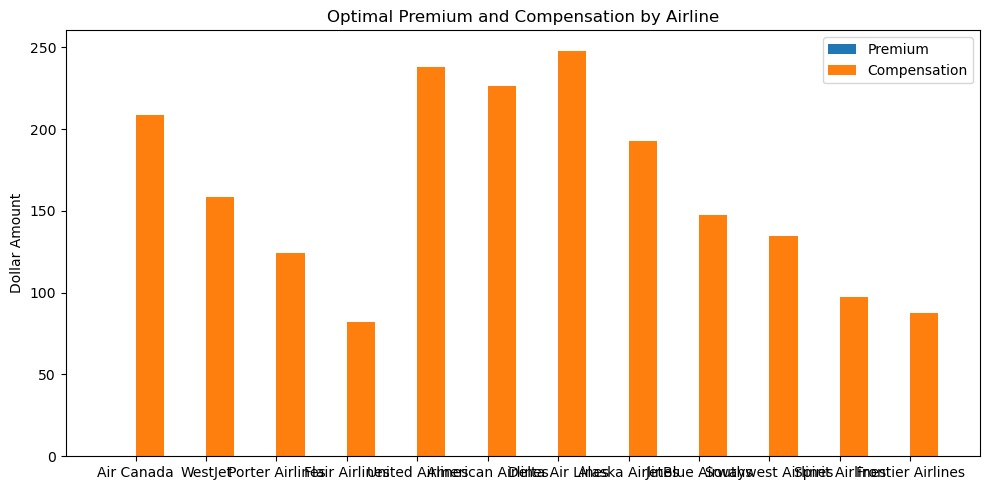

In [16]:
# Plot premium vs compensation
x_pos = np.arange(nA)

plt.figure(figsize=(10, 5))
plt.bar(x_pos - 0.2, premium_amount, width=0.4, label="Premium")
plt.bar(x_pos + 0.2, comp_amount, width=0.4, label="Compensation")

plt.xticks(x_pos, airlines)
plt.ylabel("Dollar Amount")
plt.title("Optimal Premium and Compensation by Airline")
plt.legend()
plt.tight_layout()
plt.show()

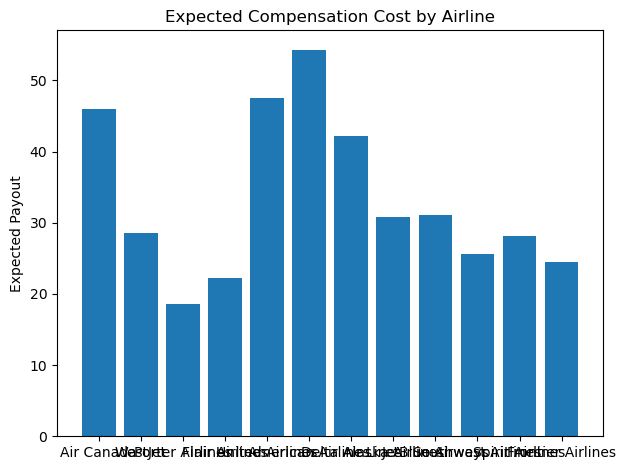

In [17]:
# Plot expected payout
plt.bar(airlines, expected_payout)

plt.ylabel("Expected Payout")
plt.title("Expected Compensation Cost by Airline")
plt.tight_layout()
plt.show()

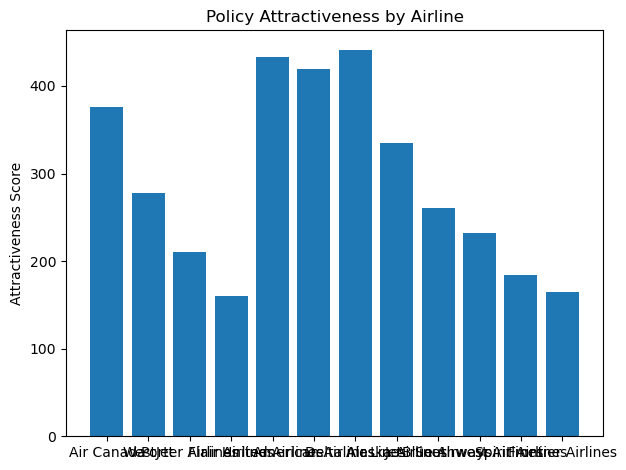

In [18]:
# Plot attractiveness
plt.bar(airlines, attractiveness)

plt.ylabel("Attractiveness Score")
plt.title("Policy Attractiveness by Airline")
plt.tight_layout()
plt.show()

Discussion

- airlines with lower delay probabilities and/or strong fare values get high compensation
- risky airlines like Flair / Spirit / Frontier get pushed close to the minimum attractiveness threshold
- the fairness constraint is clearly active for some airlines, since their attractiveness is exactly 20

But the model is just saying 'charge no premium, give as much compensation as possible to the best airlines, and give the bare minimum to the bad ones'

We know that
- insurer wants to collect premium
- customers want high compensation
- insurer dislikes risk

maybe we can change the objective function

$$
\max_{x,y} \quad
\sum_{i \in A}
\left(
\alpha x_i T_i
+ \beta(-k_i x_i T_i + m_i y_i T_i)
- q_i y_i T_i
\right)
-
\lambda \sum_{i \in A} q_i (y_i T_i)^2
$$

this would maybe create a more meaningful tradeoff

## Revised Objective Function

To address the issue where the optimal solution has no premiums, we modify the objective to include a positive term for premiums collected and account for expected payouts:

$$
\max_{x,y} \quad
\sum_{i \in A} \left(
\alpha x_i T_i
+ \beta (-k_i x_i T_i + m_i y_i T_i)
- q_i y_i T_i
\right)
-
\lambda \sum_{i \in A} q_i (y_i T_i)^2
$$

where $\alpha$ weights the premium revenue and $\beta$ weights the attractiveness.

In [27]:
# Revised objective weights
alpha = 1 # weight for premium collected
beta = 0.2  # weight for attractiveness

In [28]:
# Revised objective function
objective_revised = cp.Maximize(
    alpha * cp.sum(cp.multiply(T, x)) +
    beta * cp.sum(-cp.multiply(k * T, x) + cp.multiply(m * T, y)) -
    cp.sum(cp.multiply(q * T, y)) -
    lam * cp.sum(cp.multiply(q, cp.square(cp.multiply(T, y))))
)

In [29]:
# Solve the revised model
problem_revised = cp.Problem(objective_revised, constraints)
problem_revised.solve()

print("Revised Status:", problem_revised.status)
print("Revised optimal objective value:", problem_revised.value)

Revised Status: optimal
Revised optimal objective value: 741.6493048455602


In [30]:
# Extract revised results
premium_amount_rev = x.value * T
comp_amount_rev = y.value * T
attractiveness_rev = -k * premium_amount_rev + m * comp_amount_rev
expected_payout_rev = q * comp_amount_rev
risk_penalty_component_rev = lam * q * (comp_amount_rev ** 2)

results_rev = pd.DataFrame({
    "Airport": airlines,
    "AverageFare": T,
    "DelayProb": q,
    "PremiumFraction_x": x.value,
    "CompFraction_y": y.value,
    "PremiumAmount": premium_amount_rev,
    "CompensationAmount": comp_amount_rev,
    "Attractiveness": attractiveness_rev,
    "ExpectedPayout": expected_payout_rev,
    "RiskPenaltyComponent": risk_penalty_component_rev
})

print("Revised optimal insurance design:")
results_rev.round(4)

Revised optimal insurance design:


,Airport,AverageFare,DelayProb,PremiumFraction_x,CompFraction_y,PremiumAmount,CompensationAmount,Attractiveness,ExpectedPayout,RiskPenaltyComponent
0,Air Canada,320,0.22,0.2,0.5081,64.0,162.5906,215.8631,35.7699,5.8159
1,WestJet,280,0.18,0.2,0.6672,56.0,186.8221,262.5387,33.6280,6.2825
2,Porter Airlines,250,0.15,0.2,0.7678,50.0,191.9456,271.3076,28.7918,5.5265
3,Flair Airlines,190,0.27,0.2,0.3642,38.0,69.1893,83.6192,18.6811,1.2925
4,United Airlines,340,0.20,0.2,0.6240,68.0,212.1655,305.9011,42.4331,9.0028
5,American Airlines,330,0.24,0.2,0.4497,66.0,148.4146,194.0470,35.6195,5.2865
6,Delta Air Lines,350,0.17,0.2,0.7680,70.0,268.7961,397.2570,45.6953,12.2827
7,Alaska Airlines,310,0.16,0.2,0.7890,62.0,244.5797,356.1287,39.1328,9.5711
8,JetBlue Airways,270,0.21,0.2,0.5200,54.0,140.3932,179.5920,29.4826,4.1392
9,Southwest Airlines,260,0.19,0.2,0.5819,52.0,151.3042,200.9633,28.7478,4.3497


In [31]:
# Revised summary metrics
total_premium_rev = np.sum(premium_amount_rev)
total_attractiveness_rev = np.sum(attractiveness_rev)
total_expected_payout_rev = np.sum(expected_payout_rev)
total_risk_penalty_rev = np.sum(risk_penalty_component_rev)

print("\nRevised Summary:")
print("Total premium collected:", total_premium_rev)
print("Total attractiveness:", total_attractiveness_rev)
print("Total expected payout:", total_expected_payout_rev)
print("Total risk penalty:", total_risk_penalty_rev)
print("Net objective (before risk):", alpha * total_premium_rev + beta * total_attractiveness_rev - total_expected_payout_rev - total_risk_penalty_rev)


Revised Summary:
Total premium collected: 661.9999999730691
Total attractiveness: 2581.391546705883
Total expected payout: 371.14969005346995
Total risk penalty: 65.47931441521543
Net objective (before risk): 741.6493048455603


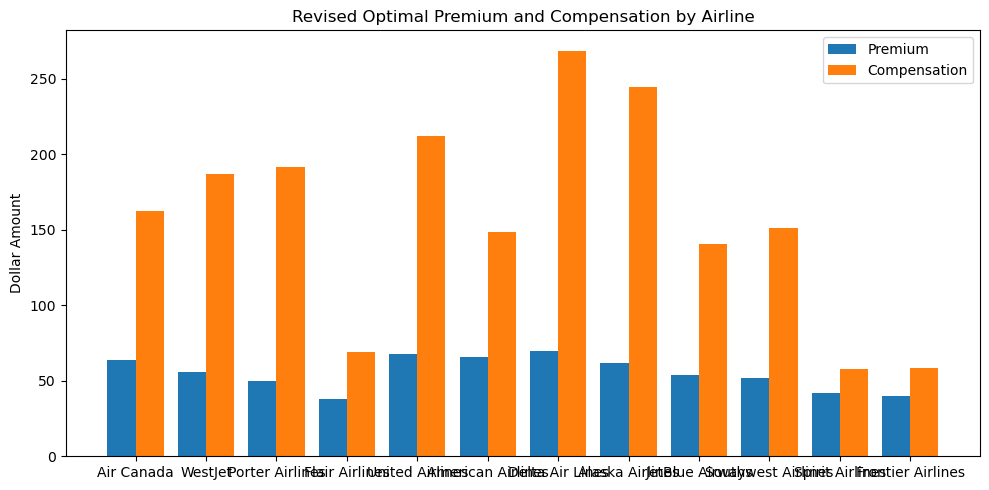

In [32]:
# Plot revised premium vs compensation
x_pos = np.arange(nA)

plt.figure(figsize=(10, 5))
plt.bar(x_pos - 0.2, premium_amount_rev, width=0.4, label="Premium")
plt.bar(x_pos + 0.2, comp_amount_rev, width=0.4, label="Compensation")

plt.xticks(x_pos, airlines)
plt.ylabel("Dollar Amount")
plt.title("Revised Optimal Premium and Compensation by Airline")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# Debug: Check the component contributions
print("=== Component Analysis ===")
print("\nPremium Revenue Contribution: alpha * total_premium =", alpha * total_premium_rev)
print("Attractiveness Contribution: beta * total_attractiveness =", beta * total_attractiveness_rev)
print("Expected Payout Cost:", total_expected_payout_rev)
print("Risk Penalty Cost:", total_risk_penalty_rev)

print("\nNote: The -k*x term in attractiveness still penalizes premiums!")
print("Net change from adding $1 in premium:")
print(f"  Gain from revenue: +{alpha}")
print(f"  Loss from attractiveness: -{np.mean(k * beta):.3f} per airline")
print(f"  This explains why premiums = 0")

# Solution: Try with much higher alpha (premium weight)
print("\n=== Testing with Higher Alpha ===")
alpha_high = 3.0  # Increase from 0.5 to 3.0
objective_revised_high = cp.Maximize(
    alpha_high * cp.sum(cp.multiply(T, x)) +
    beta * cp.sum(-cp.multiply(k * T, x) + cp.multiply(m * T, y)) -
    cp.sum(cp.multiply(q * T, y)) -
    lam * cp.sum(cp.multiply(q, cp.square(cp.multiply(T, y))))
)

problem_revised_high = cp.Problem(objective_revised_high, constraints)
problem_revised_high.solve()

premium_amount_high = x.value * T
comp_amount_high = y.value * T
total_premium_high = np.sum(premium_amount_high)

print("\nWith alpha =", alpha_high)
print("Total premium collected:", total_premium_high)
print("Average premium per airline:", total_premium_high / len(airlines))

=== Component Analysis ===

Premium Revenue Contribution: alpha * total_premium = 6.161107975101368e-06
Attractiveness Contribution: beta * total_attractiveness = 3492.203657916484
Expected Payout Cost: 397.91924666827293
Risk Penalty Cost: 71.0716287903665

Note: The -k*x term in attractiveness still penalizes premiums!
Net change from adding $1 in premium:
  Gain from revenue: +0.5
  Loss from attractiveness: -1.204 per airline
  This explains why premiums = 0

=== Testing with Higher Alpha ===

With alpha = 3.0
Total premium collected: 661.9999946101374
Average premium per airline: 55.16666621751145
